<a href="https://colab.research.google.com/github/jangirsachin9619-cpu/ml8-Deforestation-Issue-Analysis-Using-Support-Vector-Machine-SVM-/blob/main/ml8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path='/content/drive/MyDrive/Global_Pollution_Analysis.csv'
data=pd.read_csv(path)
data.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [4]:
data.isnull().sum()

,0
Country,0
Year,0
Air_Pollution_Index,0
Water_Pollution_Index,0
Soil_Pollution_Index,0
Industrial_Waste (in tons),0
Energy_Recovered (in GWh),0
CO2_Emissions (in MT),0
Renewable_Energy (%),0
Plastic_Waste_Produced (in tons),0


In [5]:
numeric_cols = data.select_dtypes(include=np.number).columns
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].mean())


In [6]:
data.fillna(data.ffill())

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Latvia,2004,115.84,78.75,42.34,49503.35,81.23,4.85,17.38,4065.66,6.28,92.96,14818.18
196,Bangladesh,2002,121.82,120.97,63.95,74694.68,25.89,46.22,16.56,36905.26,15.18,114.02,59238.04
197,Korea,2011,149.73,146.92,37.04,2818.85,293.27,38.46,38.36,24700.29,14.11,183.06,28895.94
198,Vanuatu,2002,237.20,113.63,101.96,68746.82,305.61,28.82,32.17,1443.62,12.44,40.65,17068.01


In [7]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
scaler_std=StandardScaler()
data['Air_Pollution_Index']=scaler_std.fit_transform(data[['Air_Pollution_Index']])
data['Soil_Pollution_Index']=scaler_std.fit_transform(data[['Soil_Pollution_Index']])
data['Water_Pollution_Index']=scaler_std.fit_transform(data[['Water_Pollution_Index']])
data

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,1.376167,0.193880,-0.619764,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,-1.403578,-1.153098,1.028744,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,-1.330788,-0.668076,1.142400,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,1.494394,-1.009403,0.431675,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,-0.021926,0.262567,1.138106,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Latvia,2004,-0.968336,-0.765207,-0.862482,49503.35,81.23,4.85,17.38,4065.66,6.28,92.96,14818.18
196,Bangladesh,2002,-0.878956,0.124351,-0.316683,74694.68,25.89,46.22,16.56,36905.26,15.18,114.02,59238.04
197,Korea,2011,-0.461800,0.671106,-0.996342,2818.85,293.27,38.46,38.36,24700.29,14.11,183.06,28895.94
198,Vanuatu,2002,0.845568,-0.030300,0.643326,68746.82,305.61,28.82,32.17,1443.62,12.44,40.65,17068.01


In [8]:
label_encoder = LabelEncoder()

if 'Country' in data.columns:
    data['Country_Encoded'] = label_encoder.fit_transform(data['Country'])
    data.drop('Country', axis=1, inplace=True)

data['Year']=data['Year'].astype(int)
data['Year']=label_encoder.fit_transform(data['Year'])

display(data.head())

,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Country_Encoded
0,5,1.376167,0.193880,-0.619764,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96,77
1,1,-1.403578,-1.153098,1.028744,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41,147
2,16,-1.330788,-0.668076,1.142400,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15,136
3,18,1.494394,-1.009403,0.431675,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51,38
4,8,-0.021926,0.262567,1.138106,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37,46


In [9]:
data['Total_Energy_Consumption (in MWh)'] = data['Energy_Consumption_Per_Capita (in MWh)'] * data['Population (in millions)']

display(data.head())

,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Country_Encoded,Total_Energy_Consumption (in MWh)
0,5,1.376167,0.193880,-0.619764,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96,77,530.2832
1,1,-1.403578,-1.153098,1.028744,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41,147,717.8175
2,16,-1.330788,-0.668076,1.142400,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15,136,1636.7805
3,18,1.494394,-1.009403,0.431675,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51,38,52.8840
4,8,-0.021926,0.262567,1.138106,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37,46,2394.9168


In [10]:
conditions = [
    (data['Air_Pollution_Index'] < -0.5),
    (data['Air_Pollution_Index'] >= -0.5) & (data['Air_Pollution_Index'] <= 0.5),
    (data['Air_Pollution_Index'] > 0.5)
]
choices = ['Low', 'Medium', 'High']
data['Air_Pollution_Severity'] = np.select(conditions, choices, default='Unknown')
display(data.head())

,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Country_Encoded,Total_Energy_Consumption (in MWh),Air_Pollution_Severity
0,5,1.376167,0.193880,-0.619764,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96,77,530.2832,High
1,1,-1.403578,-1.153098,1.028744,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41,147,717.8175,Low
2,16,-1.330788,-0.668076,1.142400,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15,136,1636.7805,Low
3,18,1.494394,-1.009403,0.431675,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51,38,52.8840,High
4,8,-0.021926,0.262567,1.138106,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37,46,2394.9168,Medium


In [11]:
conditions_water = [
    (data['Water_Pollution_Index'] < -0.5),
    (data['Water_Pollution_Index'] >= -0.5) & (data['Water_Pollution_Index'] <= 0.5),
    (data['Water_Pollution_Index'] > 0.5)
]
choices_water = ['Low', 'Medium', 'High']
data['Water_Pollution_Severity'] = np.select(conditions_water, choices_water, default='Unknown')
display(data.head())

,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Country_Encoded,Total_Energy_Consumption (in MWh),Air_Pollution_Severity,Water_Pollution_Severity
0,5,1.376167,0.193880,-0.619764,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96,77,530.2832,High,Medium
1,1,-1.403578,-1.153098,1.028744,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41,147,717.8175,Low,Low
2,16,-1.330788,-0.668076,1.142400,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15,136,1636.7805,Low,Low
3,18,1.494394,-1.009403,0.431675,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51,38,52.8840,High,Low
4,8,-0.021926,0.262567,1.138106,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37,46,2394.9168,Medium,Medium


In [12]:
conditions_soil = [
    (data['Soil_Pollution_Index'] < -0.5),
    (data['Soil_Pollution_Index'] >= -0.5) & (data['Soil_Pollution_Index'] <= 0.5),
    (data['Soil_Pollution_Index'] > 0.5)
]
choices_soil = ['Low', 'Medium', 'High']
data['Soil_Pollution_Severity'] = np.select(conditions_soil, choices_soil, default='Unknown')
display(data.head())

,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Country_Encoded,Total_Energy_Consumption (in MWh),Air_Pollution_Severity,Water_Pollution_Severity,Soil_Pollution_Severity
0,5,1.376167,0.193880,-0.619764,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96,77,530.2832,High,Medium,Low
1,1,-1.403578,-1.153098,1.028744,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41,147,717.8175,Low,Low,High
2,16,-1.330788,-0.668076,1.142400,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15,136,1636.7805,Low,Low,High
3,18,1.494394,-1.009403,0.431675,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51,38,52.8840,High,Low,Medium
4,8,-0.021926,0.262567,1.138106,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37,46,2394.9168,Medium,Medium,High


In [13]:
data['Energy_Recovered (in GWh)']=scaler_std.fit_transform(data[['Energy_Recovered (in GWh)']])

In [14]:
data['Renewable_Energy (%)']=scaler_std.fit_transform(data[['Renewable_Energy (%)']])
data['Industrial_Waste (in tons)']=scaler_std.fit_transform(data[['Industrial_Waste (in tons)']])
data['Plastic_Waste_Produced (in tons)']=scaler_std.fit_transform(data[['Plastic_Waste_Produced (in tons)']])

conditions = [
    (data['Energy_Recovered (in GWh)'] < -0.5),
    (data['Energy_Recovered (in GWh)'] >= -0.5) & (data['Energy_Recovered (in GWh)'] <= 0.5),
    (data['Energy_Recovered (in GWh)'] > 0.5)
]
choices = ['Low', 'Medium', 'High']
data['Energy_Recovered_Severity'] = np.select(conditions, choices, default='Unknown')

conditions = [
    (data['Renewable_Energy (%)'] < -0.5),
    (data['Renewable_Energy (%)'] >= -0.5) & (data['Renewable_Energy (%)'] <= 0.5),
    (data['Renewable_Energy (%)'] > 0.5)
]
choices = ['Low', 'Medium', 'High']
data['Renewable_Energy_Severity'] = np.select(conditions, choices, default='Unknown')

conditions = [
    (data['Industrial_Waste (in tons)'] < -0.5),
    (data['Industrial_Waste (in tons)'] >= -0.5) & (data['Industrial_Waste (in tons)'] <= 0.5),
    (data['Industrial_Waste (in tons)'] > 0.5)
]
choices = ['Low', 'Medium', 'High']
data['Industrial_Waste_Severity'] = np.select(conditions, choices, default='Unknown')

conditions = [
    (data['Plastic_Waste_Produced (in tons)'] < -0.5),
    (data['Plastic_Waste_Produced (in tons)'] >= -0.5) & (data['Plastic_Waste_Produced (in tons)'] <= 0.5),
    (data['Plastic_Waste_Produced (in tons)'] > 0.5)
]
choices = ['Low', 'Medium', 'High']
data['Plastic_Waste_Severity'] = np.select(conditions, choices, default='Unknown')

display(data.head())

,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),...,GDP_Per_Capita (in USD),Country_Encoded,Total_Energy_Consumption (in MWh),Air_Pollution_Severity,Water_Pollution_Severity,Soil_Pollution_Severity,Energy_Recovered_Severity,Renewable_Energy_Severity,Industrial_Waste_Severity,Plastic_Waste_Severity
0,5,1.376167,0.193880,-0.619764,1.543328,-0.697051,5.30,1.079423,0.874923,12.56,...,20972.96,77,530.2832,High,Medium,Low,Low,High,High,High
1,1,-1.403578,-1.153098,1.028744,0.124915,1.618760,6.34,0.700701,0.600289,5.23,...,34850.41,147,717.8175,Low,Low,High,High,High,Medium,High
2,16,-1.330788,-0.668076,1.142400,0.123888,1.560644,49.69,-1.493780,-0.395504,13.15,...,57773.15,136,1636.7805,Low,Low,High,High,Low,Medium,Medium
3,18,1.494394,-1.009403,0.431675,0.809131,-0.785350,8.91,-0.716061,-1.064327,0.78,...,21837.51,38,52.8840,High,Low,Medium,Low,Low,High,Low
4,8,-0.021926,0.262567,1.138106,0.882681,-1.499375,14.93,0.502825,1.024815,12.84,...,41379.37,46,2394.9168,Medium,Medium,High,Low,High,High,High


In [15]:
pip install mlxtend

In [16]:
severity_cols = [
    'Air_Pollution_Severity',
    'Water_Pollution_Severity',
    'Soil_Pollution_Severity',
    'Energy_Recovered_Severity',
    'Renewable_Energy_Severity',
    'Industrial_Waste_Severity',
    'Plastic_Waste_Severity'
]

df_apriori = data[severity_cols]
df_apriori = pd.get_dummies(df_apriori, dtype=bool)
display(df_apriori.head())

,Air_Pollution_Severity_High,Air_Pollution_Severity_Low,Air_Pollution_Severity_Medium,Water_Pollution_Severity_High,Water_Pollution_Severity_Low,Water_Pollution_Severity_Medium,Soil_Pollution_Severity_High,Soil_Pollution_Severity_Low,Soil_Pollution_Severity_Medium,Energy_Recovered_Severity_High,...,Energy_Recovered_Severity_Medium,Renewable_Energy_Severity_High,Renewable_Energy_Severity_Low,Renewable_Energy_Severity_Medium,Industrial_Waste_Severity_High,Industrial_Waste_Severity_Low,Industrial_Waste_Severity_Medium,Plastic_Waste_Severity_High,Plastic_Waste_Severity_Low,Plastic_Waste_Severity_Medium
0,True,False,False,False,False,True,False,True,False,False,...,False,True,False,False,True,False,False,True,False,False
1,False,True,False,False,True,False,True,False,False,True,...,False,True,False,False,False,False,True,True,False,False
2,False,True,False,False,True,False,True,False,False,True,...,False,False,True,False,False,False,True,False,False,True
3,True,False,False,False,True,False,False,False,True,False,...,False,False,True,False,True,False,False,False,True,False
4,False,False,True,False,False,True,True,False,False,False,...,False,True,False,False,True,False,False,True,False,False


In [17]:
from mlxtend.frequent_patterns import apriori
print("apriori function imported successfully.")

apriori function imported successfully.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [18]:
frequent_itemsets = apriori(df_apriori, min_support=0.1, use_colnames=True)
display(frequent_itemsets.head())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,support,itemsets
0,0.340,(Air_Pollution_Severity_High)
1,0.305,(Air_Pollution_Severity_Low)
2,0.355,(Air_Pollution_Severity_Medium)
3,0.340,(Water_Pollution_Severity_High)
4,0.355,(Water_Pollution_Severity_Low)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [19]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)
display(rules.head())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Air_Pollution_Severity_High),(Water_Pollution_Severity_High),0.340,0.340,0.125,0.367647,1.081315,1.0,0.0094,1.043721,0.113939,0.225225,0.041889,0.367647
1,(Water_Pollution_Severity_High),(Air_Pollution_Severity_High),0.340,0.340,0.125,0.367647,1.081315,1.0,0.0094,1.043721,0.113939,0.225225,0.041889,0.367647
2,(Air_Pollution_Severity_High),(Water_Pollution_Severity_Low),0.340,0.355,0.105,0.308824,0.869925,1.0,-0.0157,0.933191,-0.184706,0.177966,-0.071591,0.302299
3,(Water_Pollution_Severity_Low),(Air_Pollution_Severity_High),0.355,0.340,0.105,0.295775,0.869925,1.0,-0.0157,0.937200,-0.188193,0.177966,-0.067008,0.302299
4,(Air_Pollution_Severity_High),(Water_Pollution_Severity_Medium),0.340,0.305,0.110,0.323529,1.060752,1.0,0.0063,1.027391,0.086777,0.205607,0.026661,0.342093


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

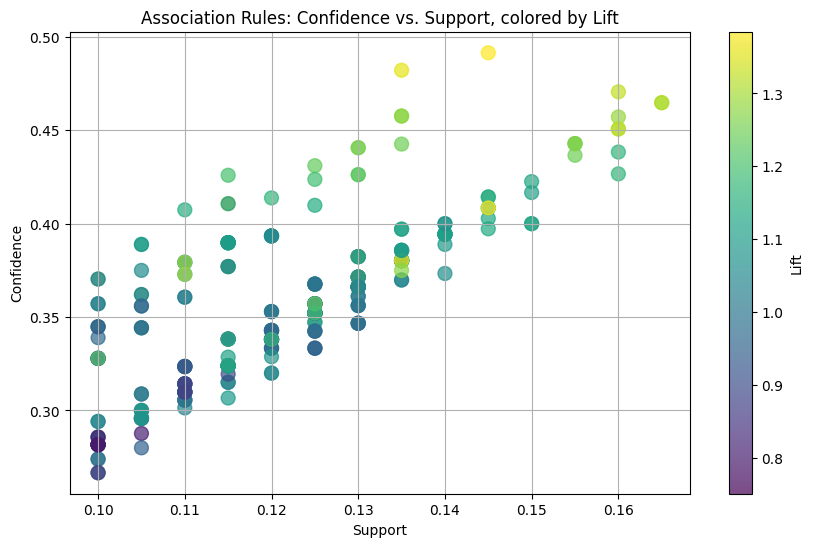

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(rules['support'], rules['confidence'], c=rules['lift'], cmap='viridis', s=100, alpha=0.7)
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rules: Confidence vs. Support, colored by Lift')
cbar = plt.colorbar()
cbar.set_label('Lift')
plt.grid(True)
plt.show()
